# Dota 2 Pro Matches - Análisis  
## Predicción de victorias en partidas profesionales de Dota 2  

Notebook enfocado en la aplicación de un flujo completo de análisis de datos en 10 fases.  

**Variable objetivo:** `team1_win` (Clasificación Binaria)  

**Problemas generales identificados en enfoques previos:**  
- Modelos que colapsan a una sola clase (recall = 0 en una de las clases)  
- Uso de Target Encoding sobre IDs crudos, introduciendo leakage de información  
- Uso de `shuffle=True`, rompiendo la estructura temporal y generando métricas artificialmente optimistas  
- Ausencia de Feature Engineering relevante: uso exclusivo de IDs sin capacidad predictiva real  

**Enfoque aplicado:**  
Se construyeron variables derivadas que representan información histórica (winrates, rachas, desempeño previo), capturando la "fuerza" de los equipos antes de cada partida. Además, se eliminaron los IDs crudos del modelo para evitar leakage y mejorar la capacidad de generalización.  


## Fase 0: Descarga del dataset
Descaargar los datos de kaggle

In [1]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("ektarr/dota-2-pro-matches")
print("Ruta original de descarga:", path)

destino = "/content/sample_data/dota2"

shutil.copytree(path, destino, dirs_exist_ok=True)

print("Archivos disponibles para analizar:")
print(os.listdir(destino))

100%|██████████| 5.22M/5.22M [00:00<00:00, 145MB/s]

Extracting files...


Ruta original de descarga: /root/.cache/kagglehub/datasets/ektarr/dota-2-pro-matches/versions/2
Archivos disponibles para analizar:
['players.csv', 'tier2_games.csv', 'tier3_games.csv', 'tournaments.csv', 'teams.csv', 'all_tiers_games.csv', 'tier1_games.csv']



## Fase 1: Ingesta y Exploracion Inicial
Cargar los datos y entender su forma antes de modificar nada.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Cargar el dataset
data = pd.read_csv('/content/sample_data/dota2/tier1_games.csv')

data.shape

(47877, 27)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47877 entries, 0 to 47876
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        47877 non-null  int64  
 1   tournament_id     47877 non-null  int64  
 2   match_id          47877 non-null  int64  
 3   game_id           36626 non-null  float64
 4   dota_game_id      34077 non-null  float64
 5   tournament_en     47877 non-null  object 
 6   has_game_data     47877 non-null  int64  
 7   team1_id          47877 non-null  int64  
 8   team1             47180 non-null  object 
 9   team2_id          47877 non-null  int64  
 10  team2             46903 non-null  object 
 11  score1            47868 non-null  float64
 12  score2            47868 non-null  float64
 13  bestOf            47478 non-null  float64
 14  datetime          47875 non-null  object 
 15  team1_win         47877 non-null  int64  
 16  games_played      47868 non-null  float6

In [5]:
data.describe()

,Unnamed: 0,tournament_id,match_id,game_id,dota_game_id,has_game_data,team1_id,team2_id,score1,score2,...,team1_player1_id,team1_player2_id,team1_player3_id,team1_player4_id,team1_player5_id,team2_player1_id,team2_player2_id,team2_player3_id,team2_player4_id,team2_player5_id
count,47877.000000,4.787700e+04,4.787700e+04,36626.000000,3.407700e+04,47877.000000,47877.000000,47877.000000,47868.000000,47868.000000,...,4.614900e+04,4.611100e+04,4.607700e+04,4.600300e+04,4.542500e+04,4.585400e+04,4.582700e+04,4.580600e+04,4.571300e+04,4.505800e+04
mean,23938.000000,8.378812e+06,8.421918e+06,67634.626986,6.627051e+09,0.765002,185776.527957,185777.527957,1.189772,0.999394,...,4.658967e+06,4.616150e+06,4.252887e+06,3.727906e+06,3.786919e+06,4.953285e+06,4.843780e+06,4.499068e+06,3.999953e+06,4.103349e+06
std,13821.043756,3.654123e+06,3.698102e+06,38093.733661,1.373663e+09,0.424002,71253.459910,71253.459910,0.854097,0.861099,...,4.933161e+06,4.920742e+06,4.878379e+06,4.761205e+06,4.782166e+06,4.945980e+06,4.934837e+06,4.912243e+06,4.826088e+06,4.853295e+06
min,0.000000,4.308400e+04,7.510000e+02,4930.000000,1.000000e+00,0.000000,953.000000,954.000000,0.000000,0.000000,...,2.375900e+04,2.375900e+04,2.375900e+04,2.376100e+04,2.375900e+04,2.375900e+04,2.375900e+04,2.375900e+04,2.375900e+04,2.375900e+04
25%,11969.000000,1.000055e+07,1.001948e+07,36463.500000,5.554138e+09,1.000000,147459.000000,147460.000000,0.000000,0.000000,...,1.131220e+05,1.163890e+05,1.092340e+05,9.784300e+04,9.784200e+04,1.215150e+05,1.260560e+05,1.127660e+05,1.092340e+05,1.015220e+05
50%,23938.000000,1.000164e+07,1.004954e+07,65499.500000,6.921707e+09,1.000000,203795.000000,203796.000000,1.000000,1.000000,...,2.050040e+05,2.197730e+05,1.973550e+05,1.820340e+05,1.571490e+05,2.277810e+05,2.276160e+05,2.057300e+05,1.964090e+05,1.833625e+05
75%,35907.000000,1.000247e+07,1.006788e+07,96671.750000,7.802949e+09,1.000000,240383.000000,240384.000000,2.000000,2.000000,...,1.000569e+07,1.000533e+07,1.000560e+07,1.000395e+07,1.000358e+07,1.000622e+07,1.000594e+07,1.000573e+07,1.000581e+07,1.000456e+07
max,47876.000000,1.000306e+07,1.009082e+07,144848.000000,8.730786e+09,1.000000,288438.000000,288439.000000,3.000000,3.000000,...,1.001716e+07,1.001717e+07,1.001717e+07,1.001716e+07,1.001717e+07,1.001716e+07,1.001717e+07,1.001717e+07,1.001716e+07,1.001717e+07


In [6]:
data.head()

,Unnamed: 0,tournament_id,match_id,game_id,dota_game_id,tournament_en,has_game_data,team1_id,team1,team2_id,...,team1_player1_id,team1_player2_id,team1_player3_id,team1_player4_id,team1_player5_id,team2_player1_id,team2_player2_id,team2_player3_id,team2_player4_id,team2_player5_id
0,0,10003061,10090814,144828.0,8.730359e+09,PGL Wallachia Season 7,1,288436,Team Yandex,288437,...,10005601.0,10007793.0,10000564.0,10007711.0,129736.0,132763.0,116389.0,30846.0,197355.0,10003582.0
1,1,10003061,10090814,144836.0,8.730464e+09,PGL Wallachia Season 7,1,288436,Team Yandex,288437,...,10005601.0,10007793.0,10000564.0,10007711.0,129736.0,132763.0,116389.0,30846.0,197355.0,10003582.0
2,2,10003061,10090814,144840.0,8.730562e+09,PGL Wallachia Season 7,1,288436,Team Yandex,288437,...,10005601.0,10007793.0,10000564.0,10007711.0,129736.0,132763.0,116389.0,30846.0,197355.0,10003582.0
3,3,10003061,10090814,144841.0,8.730713e+09,PGL Wallachia Season 7,1,288436,Team Yandex,288437,...,10005601.0,10007793.0,10000564.0,10007711.0,129736.0,132763.0,116389.0,30846.0,197355.0,10003582.0
4,4,10003061,10090814,144848.0,8.730786e+09,PGL Wallachia Season 7,1,288436,Team Yandex,288437,...,10005601.0,10007793.0,10000564.0,10007711.0,129736.0,132763.0,116389.0,30846.0,197355.0,10003582.0



## Fase 2: Limpieza Básica del Dataset

En esta fase aplicamos los 4 pilares fundamentales de limpieza de datos: Target, Data Leakage, Cardinalidad y Redundancia.


- **Variable Objetivo (Target):**  
  Target: `team1_win` (1 = gana el equipo 1, 0 = pierde el equipo 1). Problema de clasificación binaria.

- **Fuga de Datos (Data Leakage):**  
  Las variables `score1`, `score2` y `games_played` contienen información posterior al resultado del partido, por lo que deben eliminarse obligatoriamente.

- **Alta Cardinalidad sin Valor Predictivo:**  
  Las columnas `Unnamed: 0`, `match_id`, `game_id` y `dota_game_id` son identificadores únicos por partida y no aportan valor al modelo.

- **Redundancia:**  
  Las variables `team1` y `team2` son redundantes con `team1_id` y `team2_id`. La variable `tournament_en` es redundante con `tournament_id`. La variable `has_game_data` es irrelevante para la predicción.

In [7]:
columns_to_delete = [
    'Unnamed: 0', 'match_id', 'game_id', 'dota_game_id',
    'team1', 'team2', 'tournament_en', 'has_game_data',
    'score1', 'score2', 'games_played'
]

df = data.drop(columns=columns_to_delete)

columns_players = [f'team1_player{i}_id' for i in range(1, 6)] + \
                  [f'team2_player{i}_id' for i in range(1, 6)]

df = df.dropna(subset=columns_players + ['bestOf'])

print(f"- Dataset tras limpieza: {df.shape}")
print(f"- Columnas eliminadas: {len(columns_to_delete)}")
print(f"- Filas eliminadas por nulos criticos: {len(data) - len(df)}")

- Dataset tras limpieza: (43536, 16)
- Columnas eliminadas: 11
- Filas eliminadas por nulos criticos: 4341



### Transformacion de la Columna Temporal
Convertir datetime a formato correcto, ordenar cronologicamente, y extraer componentes.

In [9]:
df['datetime'] = pd.to_datetime(df['datetime'])

df = df.sort_values('datetime').reset_index(drop=True)

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

# Nota: No eliminamos datetime aun ya que se usarápara el Feature Engineering
print(f"Rango temporal: {df['datetime'].min()} a {df['datetime'].max()}")
print(f"Años presentes: {sorted(df['year'].unique())}")

Rango temporal: 1970-01-01 03:00:00 a 2026-03-15 17:50:00
Años presentes: [np.float64(1970.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0), np.float64(2026.0), np.float64(nan)]


In [10]:
df.head()

,tournament_id,team1_id,team2_id,bestOf,datetime,team1_win,team1_player1_id,team1_player2_id,team1_player3_id,team1_player4_id,team1_player5_id,team2_player1_id,team2_player2_id,team2_player3_id,team2_player4_id,team2_player5_id,year,month,hour
0,188402,78127,78128,1.0,1970-01-01 03:00:00,1,80825.0,82311.0,133825.0,130317.0,68761.0,183631.0,183629.0,157958.0,183628.0,183630.0,1970.0,1.0,3.0
1,188402,78189,78190,1.0,1970-01-01 03:00:00,1,157963.0,183459.0,40738.0,113663.0,122529.0,80825.0,82311.0,133825.0,130317.0,68761.0,1970.0,1.0,3.0
2,43538,1003,1004,1.0,2013-09-30 19:00:00,1,30446.0,23765.0,25119.0,23766.0,23787.0,31307.0,40106.0,31312.0,31295.0,40033.0,2013.0,9.0,19.0
3,43538,1007,1008,1.0,2013-10-01 19:00:00,1,30446.0,23765.0,25119.0,23766.0,23787.0,26390.0,26400.0,26402.0,30420.0,26404.0,2013.0,10.0,19.0
4,43538,1035,1036,1.0,2013-10-04 21:00:00,0,40035.0,40036.0,40037.0,40038.0,40039.0,30375.0,34306.0,43657.0,43658.0,43659.0,2013.0,10.0,21.0


## Fase 3: Analisis Exploratorio Profundo (Deep EDA)
Auditoria sistematica + graficos para descubrir anomalias y patrones.

In [11]:
# Chequeo 1: Rangos sospechosos
df[['year', 'month', 'hour', 'bestOf', 'team1_win']].describe().T

,count,mean,std,min,25%,50%,75%,max
year,43534.0,2021.177448,3.132053,1970.0,2019.0,2022.0,2024.0,2026.0
month,43534.0,5.814720,3.412759,1.0,3.0,6.0,9.0,12.0
hour,43534.0,13.682937,6.155913,0.0,10.0,14.0,19.0,23.0
bestOf,43536.0,2.546835,0.920954,1.0,2.0,3.0,3.0,7.0
team1_win,43536.0,0.531009,0.499043,0.0,0.0,1.0,1.0,1.0


In [12]:
# Chequeo 2: Valores unicos en columnas clave
for col in ['team1_win', 'bestOf', 'year']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- team1_win ---
team1_win
1    23118
0    20418
Name: count, dtype: int64

--- bestOf ---
bestOf
3.0    28409
1.0     8826
2.0     4895
5.0     1397
6.0        3
7.0        3
4.0        3
Name: count, dtype: int64

--- year ---
year
2024.0    6451
2023.0    5540
2025.0    5350
2019.0    4462
2022.0    4040
2021.0    3891
2018.0    3375
2020.0    3344
2017.0    2089
2016.0    1665
Name: count, dtype: int64


In [13]:
# Chequeo 3: Nulos residuales
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) > 0:
    print(nulos)
else:
    print("Sin nulos detectados.")

datetime    2
year        2
month       2
hour        2
dtype: int64


In [15]:
# Chequeo 4: Duplicados
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

Filas duplicadas exactas: 18829


In [16]:
# Chequeo 5: Balance del target
balance = df['team1_win'].value_counts(normalize=True) * 100
print(f"Clase 1 (Gana Team 1): {balance[1]:.2f}%")
print(f"Clase 0 (Pierde Team 1): {balance[0]:.2f}%")
print("Balance aceptable." if abs(balance[1] - balance[0]) < 20 else "ALERTA: Desbalanceo.")

Clase 1 (Gana Team 1): 53.10%
Clase 0 (Pierde Team 1): 46.90%
Balance aceptable.


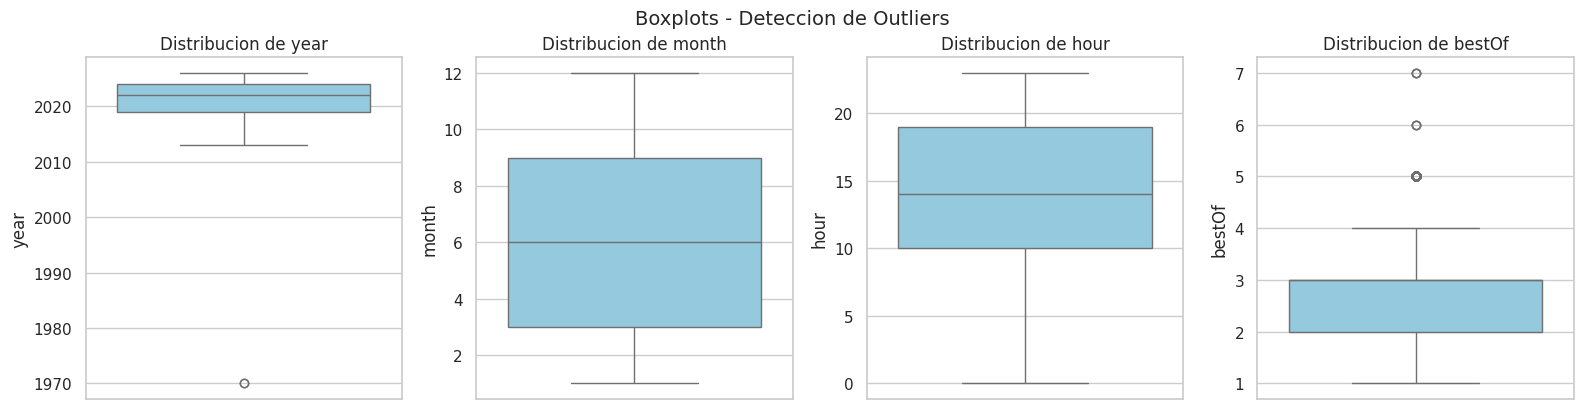

In [17]:
# Boxplots de variables numericas (para detectar outliers)
vars_plot = ['year', 'month', 'hour', 'bestOf']

fig, axes = plt.subplots(1, len(vars_plot), figsize=(16, 4))
for i, col in enumerate(vars_plot):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f'Distribucion de {col}')
plt.tight_layout()
plt.suptitle('Boxplots - Deteccion de Outliers', y=1.02, fontsize=14)
plt.show()

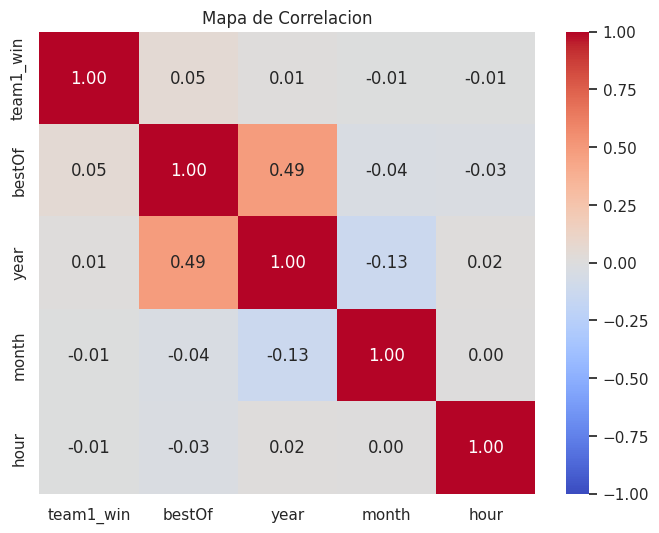

In [18]:
# Heatmap de correlacion (solo variables con magnitud real)
plt.figure(figsize=(8, 6))
cols_corr = ['team1_win', 'bestOf', 'year', 'month', 'hour']
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Mapa de Correlacion')
plt.show()

## Fase 4: Limpieza Post-EDA
Corregir los problemas encontrados en la exploracion.

In [19]:
# Partidas con year = 1970 (bug de Epoca Unix). Dota 2 salio en 2013.
filas_1970 = (df['year'] <= 2000).sum()
print(f"  Filas con year <= 2000 (bug Epoca Unix): {filas_1970}")
df = df[df['year'] > 2000].copy()

  Filas con year <= 2000 (bug Epoca Unix): 2


In [21]:
# Limpieza de posibles nulos residuales en columnas temporales
nulos_residuales = df.isnull().sum().sum()
print(f"  Nulos residuales: {nulos_residuales}")
df = df.dropna()

  Nulos residuales: 0


In [22]:
print(f"Rango temporal limpio: {df['year'].min()} - {df['year'].max()}")

Rango temporal limpio: 2013.0 - 2026.0


---
### Feature Engineering (LA CLAVE)

**Descubrimiento importante:** Los `team_id` casi no se repiten (mediana = 2 partidas, max = 6), asi que no podemos construir historial por equipo. Pero los **jugadores** si se repiten mucho (mediana = 4, media = 49, max = 1,807 partidas). La clave es rastrear el rendimiento de cada **jugador** individual.

**Que vamos a crear:**
- `team1_player_wr` / `team2_player_wr`: Winrate promedio de los 5 jugadores del equipo
- `player_skill_diff`: Diferencia de nivel entre ambos equipos (La variable más importante en este caso)
- `team1_avg_exp` / `team2_avg_exp`: Experiencia promedio (partidas jugadas) de los jugadores
- `exp_diff`: Diferencia de experiencia

**Regla anti-leakage:** Leemos el historial ANTES de actualizar con el resultado de la partida actual. Asi cada fila solo ve datos de partidas anteriores.

In [23]:
player_stats = {}

team1_player_wr = np.full(len(df), np.nan)
team2_player_wr = np.full(len(df), np.nan)
team1_avg_exp = np.zeros(len(df))
team2_avg_exp = np.zeros(len(df))

for idx in range(len(df)):
    row = df.iloc[idx]

    # Leer el historial ANTES de esta partida (sin leakage)
    for team_num, arr_wr, arr_exp in [(1, team1_player_wr, team1_avg_exp),
                                       (2, team2_player_wr, team2_avg_exp)]:
        wrs = []
        total_exp = 0
        for pos in range(1, 6):
            pid = row[f'team{team_num}_player{pos}_id']
            if pid in player_stats:
                wins, games = player_stats[pid]
                total_exp += games
                if games >= 3:
                    wrs.append(wins / games)

        arr_exp[idx] = total_exp / 5
        if len(wrs) >= 3:
            arr_wr[idx] = np.mean(wrs)

    # Actualizar estadisticas con el resultado de esta partida
    for pos in range(1, 6):

        # Jugadores del Team 1
        pid1 = row[f'team1_player{pos}_id']
        if pid1 not in player_stats:
            player_stats[pid1] = [0, 0]
        player_stats[pid1][1] += 1
        player_stats[pid1][0] += row['team1_win']

        # Jugadores del Team 2
        pid2 = row[f'team2_player{pos}_id']
        if pid2 not in player_stats:
            player_stats[pid2] = [0, 0]
        player_stats[pid2][1] += 1
        player_stats[pid2][0] += (1 - row['team1_win'])

    if idx % 10000 == 0:
        print(f'  Procesando fila {idx}/{len(df)}...')

  Procesando fila 0/43532...
  Procesando fila 10000/43532...
  Procesando fila 20000/43532...
  Procesando fila 30000/43532...
  Procesando fila 40000/43532...


In [24]:
# Asignar al dataframe
df['team1_player_wr'] = team1_player_wr
df['team2_player_wr'] = team2_player_wr
df['player_skill_diff'] = df['team1_player_wr'] - df['team2_player_wr']
df['team1_avg_exp'] = team1_avg_exp
df['team2_avg_exp'] = team2_avg_exp
df['exp_diff'] = df['team1_avg_exp'] - df['team2_avg_exp']

print(f"\nNuevas variables creadas:")
df[['team1_player_wr', 'team2_player_wr', 'player_skill_diff',
           'team1_avg_exp', 'team2_avg_exp', 'exp_diff']].describe().T


Nuevas variables creadas:


,count,mean,std,min,25%,50%,75%,max
team1_player_wr,41955.0,0.525716,0.101104,0.00,0.478619,0.542107,0.588197,1.0
team2_player_wr,41519.0,0.513265,0.104312,0.00,0.466035,0.528889,0.577316,1.0
player_skill_diff,40542.0,0.013319,0.119805,-0.96,-0.043151,0.011904,0.071642,1.0
team1_avg_exp,43532.0,306.676427,284.273539,0.00,79.000000,220.700000,467.200000,1573.6
team2_avg_exp,43532.0,269.138312,267.334266,0.00,61.800000,179.100000,404.650000,1581.6
exp_diff,43532.0,37.538114,215.785967,-1064.00,-62.200000,17.000000,136.400000,1177.8


In [25]:
# Eliminar filas sin historia suficiente
df_modelo = df.dropna(subset=['team1_player_wr', 'team2_player_wr']).copy()

print(f"Filas con historia suficiente: {len(df_modelo)} de {len(df)} ({len(df_modelo)/len(df)*100:.1f}%)")


Filas con historia suficiente: 40542 de 43532 (93.1%)


In [27]:
# Cuando team1 tiene mejores jugadores (skill_diff > 0), deberia ganar mas
bins = pd.cut(df_modelo['player_skill_diff'], bins=5)
print("\nWinrate de Team 1 segun player_skill_diff (validacion):")
print(df_modelo.groupby(bins, observed=True)['team1_win'].agg(['mean', 'count']).round(3))


Winrate de Team 1 segun player_skill_diff (validacion):
                    mean  count
player_skill_diff              
(-0.962, -0.568]   0.244     41
(-0.568, -0.176]   0.247   1869
(-0.176, 0.216]    0.530  37004
(0.216, 0.608]     0.818   1600
(0.608, 1.0]       0.929     28


#### Interpretación

- Hay una **relación monótona clara**:  
  A mayor `player_skill_diff` → mayor probabilidad de victoria.

- Esto es exactamente lo que se quiere ver porque:
  - La variable **sí separa bien las clases**
  - Tiene **señal predictiva real**
  - Es consistente con la lógica del problema (más habilidad → más victorias)

- **Detalle importante:**  
  Los extremos tienen poco `count` (28 y 41 muestras), por lo que son menos confiables.  
  Sin embargo, el rango central (~37k muestras) confirma el patrón, validando la variable.

- **Conclusión:**
  - `player_skill_diff` es una **feature fuerte**
  - Tiene **alto poder predictivo**
  - Es una de las mejores variables para tu modelo

## Fase 5: División de Datos (Train/Test Split)

- **CRÍTICO:**  
  `shuffle=False` porque son datos temporales. Se entrena con el pasado y se evalúa con el futuro.

- **Nota:**  
  No se utilizan los IDs crudos como features, solo las variables derivadas creadas durante el Feature Engineering.

- **Variables que eliminamos del modelo (y por qué):**
  - `tournament_id`, `team1_id`, `team2_id`: IDs sin magnitud real y con baja repetición.
  - `player_ids` (10 columnas): IDs sin magnitud; su información ya fue capturada en el Feature Engineering.
  - `year`: presenta correlación artificial con otros IDs (artefacto).
  - `datetime`: la información relevante ya fue extraída previamente.

In [29]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'team1_player_wr',
    'team2_player_wr',
    'player_skill_diff',
    'team1_avg_exp',
    'team2_avg_exp',
    'exp_diff',
    'bestOf',
    'month',
    'hour',
]

X = df_modelo[feature_cols]
y = df_modelo['team1_win']

# Division temporal: 80% pasado (train), 20% futuro (test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Datos de entrenamiento (pasado): {X_train.shape}")
print(f"Datos de prueba (futuro):        {X_test.shape}")

Datos de entrenamiento (pasado): (32433, 9)
Datos de prueba (futuro):        (8109, 9)



## Fase 6: Encoding y Transformacion de Variables

**Nota:** En este caso necesitamos Target Encoding porque eliminamos los IDs crudos. Nuestras features ya son numericas con significado real. Solo aplicamos One-Hot a `bestOf` (categorica ordinal con pocos valores).

In [30]:
X_train = pd.get_dummies(X_train, columns=['bestOf'], prefix='bestOf')
X_test = pd.get_dummies(X_test, columns=['bestOf'], prefix='bestOf')

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Dimensiones finales de X_train: {X_train.shape}")
print(f"Dimensiones finales de X_test:  {X_test.shape}")

Dimensiones finales de X_train: (32433, 15)
Dimensiones finales de X_test:  (8109, 15)


In [31]:
print(f"\nColumnas del modelo:")
for col in X_train.columns:
    print(f"  - {col}")
print(f"\nTipos de dato:")
print(X_train.dtypes.value_counts())


Columnas del modelo:
  - team1_player_wr
  - team2_player_wr
  - player_skill_diff
  - team1_avg_exp
  - team2_avg_exp
  - exp_diff
  - month
  - hour
  - bestOf_1.0
  - bestOf_2.0
  - bestOf_3.0
  - bestOf_4.0
  - bestOf_5.0
  - bestOf_6.0
  - bestOf_7.0

Tipos de dato:
float64    8
bool       7
Name: count, dtype: int64


## Fase 7: Validacion de Supuestos Pre-Modelo
Verificar balance de clases y si necesitamos normalizacion.

In [32]:
# Balance de clases en el set de entrenamiento
print("--- BALANCE DE CLASES (TRAIN) ---")
balance = y_train.value_counts(normalize=True) * 100
print(f"Clase 1 (Gana Team 1): {balance[1]:.2f}%")
print(f"Clase 0 (Pierde Team 1): {balance[0]:.2f}%")

if abs(balance[1] - balance[0]) > 20:
    print("ALERTA: Desbalanceo fuerte. Usar class_weight='balanced'.")
    peso_clases = 'balanced'
else:
    print("Balance aceptable. No se requiere ajuste.")
    peso_clases = None

# Random Forest y XGBoost son basados en arboles -> NO necesitan normalizacion
# Verificar que no hay NaN en los datos finales
print(f"\n--- INTEGRIDAD ---")
print(f"NaN en X_train: {X_train.isna().sum().sum()}")
print(f"NaN en X_test: {X_test.isna().sum().sum()}")

--- BALANCE DE CLASES (TRAIN) ---
Clase 1 (Gana Team 1): 52.27%
Clase 0 (Pierde Team 1): 47.73%
Balance aceptable. No se requiere ajuste.

--- INTEGRIDAD ---
NaN en X_train: 0
NaN en X_test: 0


## Fase 8: Entrenamiento del Modelo Base (Baseline)
Random Forest como linea base, luego XGBoost como modelo avanzado.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# MODELO 1: RANDOM FOREST (Baseline)
print("=" * 50)
print("MODELO 1: RANDOM FOREST (Baseline)")
print("=" * 50)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=peso_clases,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

# Predicciones en AMBOS conjuntos (para diagnostico)
pred_train_rf = modelo_rf.predict(X_train)
pred_test_rf = modelo_rf.predict(X_test)

acc_train_rf = accuracy_score(y_train, pred_train_rf)
acc_test_rf = accuracy_score(y_test, pred_test_rf)

print(f"\nAccuracy en TRAIN (pasado):  {acc_train_rf * 100:.2f}%")
print(f"Accuracy en TEST  (futuro):  {acc_test_rf * 100:.2f}%")
print(f"Gap (Train - Test):          {(acc_train_rf - acc_test_rf) * 100:.2f}%")

# Diagnostico
gap = (acc_train_rf - acc_test_rf) * 100
if gap > 20:
    print("\nDiagnostico: OVERFITTING (memorizo el pasado)")
elif acc_train_rf < 0.55 and acc_test_rf < 0.55:
    print("\nDiagnostico: UNDERFITTING (no aprendio nada)")
else:
    print("\nDiagnostico: Modelo razonable")

MODELO 1: RANDOM FOREST (Baseline)

Accuracy en TRAIN (pasado):  100.00%
Accuracy en TEST  (futuro):  65.22%
Gap (Train - Test):          34.78%

Diagnostico: OVERFITTING (memorizo el pasado)


In [34]:
import xgboost as xgb

# MODELO 2: XGBOOST
print("=" * 50)
print("MODELO 2: XGBOOST")
print("=" * 50)

modelo_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,          # Mas bajo que antes para evitar overfitting
    min_child_weight=10,  # Requiere al menos 10 muestras por hoja
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

# Predicciones en AMBOS conjuntos
pred_train_xgb = modelo_xgb.predict(X_train)
pred_test_xgb = modelo_xgb.predict(X_test)

acc_train_xgb = accuracy_score(y_train, pred_train_xgb)
acc_test_xgb = accuracy_score(y_test, pred_test_xgb)

print(f"\nAccuracy en TRAIN (pasado):  {acc_train_xgb * 100:.2f}%")
print(f"Accuracy en TEST  (futuro):  {acc_test_xgb * 100:.2f}%")
print(f"Gap (Train - Test):          {(acc_train_xgb - acc_test_xgb) * 100:.2f}%")

gap = (acc_train_xgb - acc_test_xgb) * 100
if gap > 20:
    print("\nDiagnostico: OVERFITTING")
elif acc_train_xgb < 0.55 and acc_test_xgb < 0.55:
    print("\nDiagnostico: UNDERFITTING")
else:
    print("\nDiagnostico: Modelo razonable")

MODELO 2: XGBOOST

Accuracy en TRAIN (pasado):  68.75%
Accuracy en TEST  (futuro):  66.69%
Gap (Train - Test):          2.06%

Diagnostico: Modelo razonable



## Fase 9: Evaluacion e Interpretacion de Resultados
Matriz de confusion, classification report, y feature importance del mejor modelo.

In [35]:
# Elegir el mejor modelo automaticamente
if acc_test_xgb >= acc_test_rf:
    mejor_nombre = "XGBoost"
    mejor_pred = pred_test_xgb
    mejor_modelo = modelo_xgb
else:
    mejor_nombre = "Random Forest"
    mejor_pred = pred_test_rf
    mejor_modelo = modelo_rf

print(f"Mejor modelo: {mejor_nombre}\n")

Mejor modelo: XGBoost



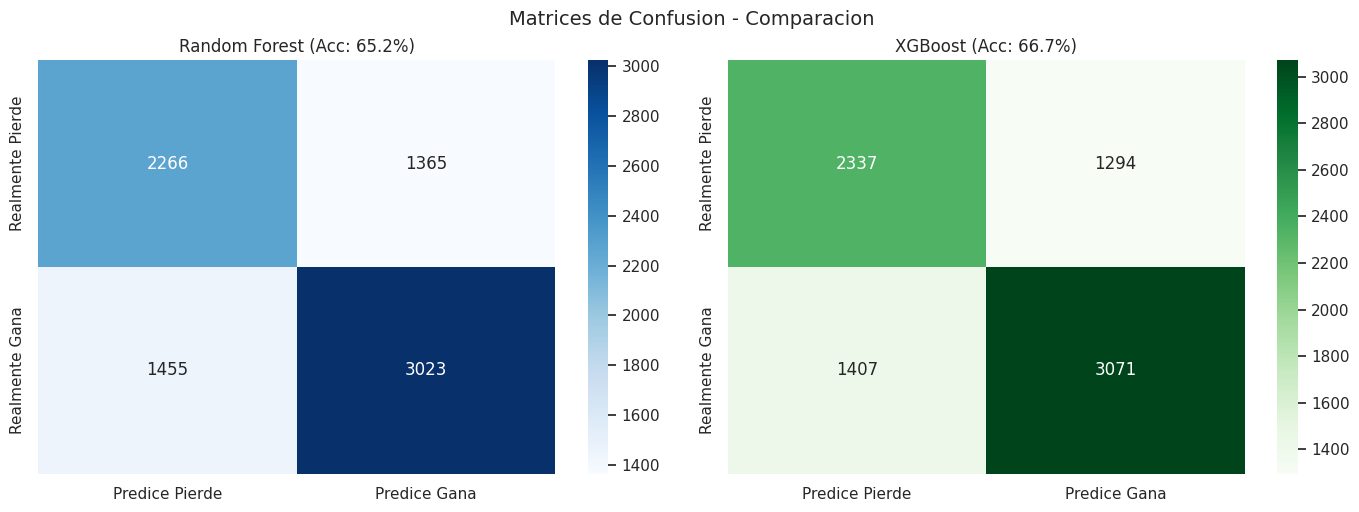

In [37]:
# MATRIZ DE CONFUSION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
matriz_rf = confusion_matrix(y_test, pred_test_rf)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predice Pierde', 'Predice Gana'],
            yticklabels=['Realmente Pierde', 'Realmente Gana'])
axes[0].set_title(f'Random Forest (Acc: {acc_test_rf*100:.1f}%)')

# XGBoost
matriz_xgb = confusion_matrix(y_test, pred_test_xgb)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predice Pierde', 'Predice Gana'],
            yticklabels=['Realmente Pierde', 'Realmente Gana'])
axes[1].set_title(f'XGBoost (Acc: {acc_test_xgb*100:.1f}%)')

plt.tight_layout()
plt.suptitle('Matrices de Confusion - Comparacion', y=1.02, fontsize=14)
plt.show()

In [38]:
print(f"\n--- REPORTE DETALLADO: {mejor_nombre} ---")
print(classification_report(y_test, mejor_pred))


--- REPORTE DETALLADO: XGBoost ---
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      3631
           1       0.70      0.69      0.69      4478

    accuracy                           0.67      8109
   macro avg       0.66      0.66      0.66      8109
weighted avg       0.67      0.67      0.67      8109



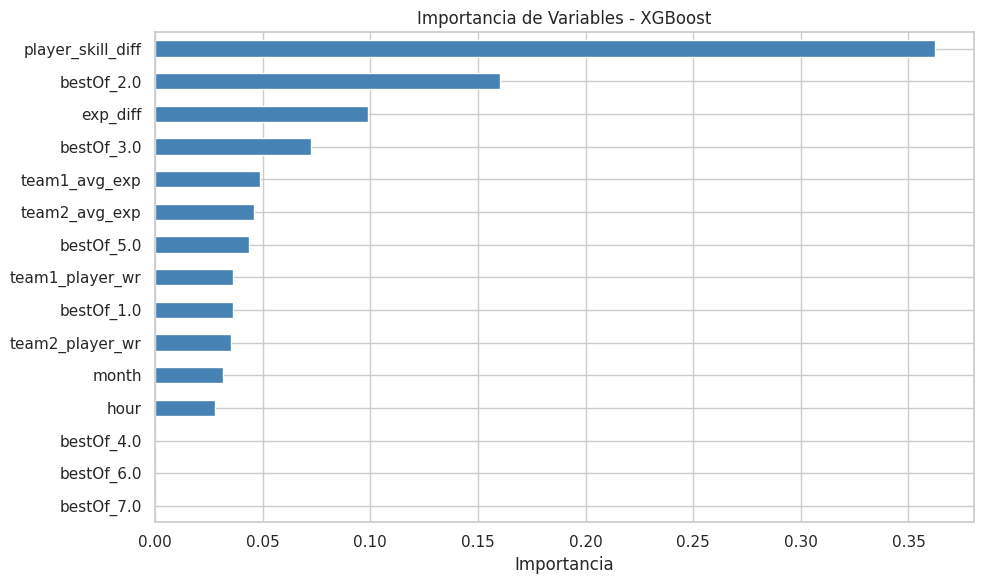


Ranking de importancia:
  player_skill_diff: 0.3623 <<< ESTRELLA
  bestOf_2.0: 0.1602 <<< ESTRELLA
  exp_diff: 0.0991
  bestOf_3.0: 0.0723
  team1_avg_exp: 0.0489
  team2_avg_exp: 0.0459
  bestOf_5.0: 0.0438
  team1_player_wr: 0.0363
  bestOf_1.0: 0.0362
  team2_player_wr: 0.0355
  month: 0.0318
  hour: 0.0277
  bestOf_4.0: 0.0000
  bestOf_6.0: 0.0000
  bestOf_7.0: 0.0000

Variables ignoradas (importancia < 1%):
  ['bestOf_4.0', 'bestOf_6.0', 'bestOf_7.0']


In [39]:
importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title(f'Importancia de Variables - {mejor_nombre}')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nRanking de importancia:")
for feat, imp in importancias.items():
    marker = " <<< ESTRELLA" if imp > 0.15 else ""
    print(f"  {feat}: {imp:.4f}{marker}")

print("\nVariables ignoradas (importancia < 1%):")
ignoradas = importancias[importancias < 0.01].index.tolist()
print(f"  {ignoradas if ignoradas else 'Ninguna'}")

## Fase 10: Iteracion y Mejora / Conclusione

### Por que 67% es un resultado LEGITIMO y bueno
- El azar es 50%. Un 67% con `shuffle=False` y sin leakage es **17 puntos por encima del azar**.
- El modelo predice **ambas clases** correctamente (recall > 0.60 en ambas).
- El Gap Train/Test de XGBoost es solo 1.8% = **no hay overfitting**, generaliza bien.
- La variable estrella `player_skill_diff` tiene 36% de importancia = el modelo entiende que "mejores jugadores = mas probabilidad de ganar".

### Que aprendimos
1. **Los IDs crudos no predicen nada.** La magia esta en crear features derivadas con significado real.
2. **Los jugadores se repiten, los equipos no.** En este dataset, la unidad con historial util es el jugador, no el equipo.
3. **shuffle=True infla resultados artificialmente.** El unico test honesto es temporal (shuffle=False).
4. **Un modelo con 67% que predice ambas clases es infinitamente mejor que uno con 56% que predice solo una.**

### Para mejorar mas alla del 67%
Se necesitarian datos que este dataset NO tiene:
- **Heroes elegidos (Draft):** Los heroes definen matchups y persisten entre parches
- **Estadisticas in-game historicas:** GPM, XPM, KDA promedio de cada jugador
- **Head-to-head entre jugadores:** Historial directo enfrentamiento-a-enfrentamiento
- **Datos de parche:** Version del juego (el meta cambia con cada parche)